In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

In [7]:
factors = ["hidden_size", "n_head", "num_layers", "epoch_number", "LR", "dropout", "batch_size", "grad_clip"]

In [9]:
runs = pd.read_csv("../model_results_TFT_20251010_112238.csv")
runs['is_center'] = False
runs.loc[runs['hidden_size'] == 64, 'is_center'] = True
runs.tail(10)

,seed,deleted_samples,window_size,test_size,hidden_size,n_head,num_layers,epoch_number,Target,LR,dropout,batch_size,grad_clip,MAE,MAPE,MSE,RMSE,r2,runtime,is_center
126,1048596,12,8,4,8,2,3,30,SE,0.10000,0.5,128,1.0,854.019989,44.511857,1.007485e+06,854.019989,-inf,37.339751,False
127,1048596,12,8,4,8,2,3,30,NAW,0.00001,0.1,16,1.0,676.098694,16.966579,1.258746e+06,676.098694,-inf,211.703309,False
128,1048596,12,8,4,64,4,2,75,FE,0.00100,0.3,64,0.1,825.741150,22.432529,1.321113e+06,825.741150,-inf,190.340400,True
129,1048596,12,8,4,64,4,2,75,IND,0.00100,0.3,64,0.1,711.913940,38.985780,8.306345e+05,711.913940,-inf,197.307207,True
130,1048596,12,8,4,64,4,2,75,NAE,0.00100,0.3,64,0.1,921.895416,85.479313,9.690844e+05,921.895416,-inf,198.311521,True
131,1048596,12,8,4,64,4,2,75,NE,0.00100,0.3,64,0.1,802.993103,29.193523,1.302205e+06,802.993103,-inf,195.949954,True
132,1048596,12,8,4,64,4,2,75,SAE,0.00100,0.3,64,0.1,379.187866,10.709775,2.625456e+05,379.187866,-inf,192.234171,True
133,1048596,12,8,4,64,4,2,75,SAW,0.00100,0.3,64,0.1,636.017395,61.226867,4.638468e+05,636.017395,-inf,191.648613,True
134,1048596,12,8,4,64,4,2,75,SE,0.00100,0.3,64,0.1,855.176666,48.660547,1.072950e+06,855.176666,-inf,195.443079,True
135,1048596,12,8,4,64,4,2,75,NAW,0.00100,0.3,64,0.1,1135.383728,31.763725,2.643636e+06,1135.383728,-inf,198.120579,True


In [27]:
runs['runtime'].describe()

count     136.000000
mean      347.597833
std       370.931159
min        37.039848
25%       129.341829
50%       195.696517
75%       296.173244
max      1183.929488
Name: runtime, dtype: float64

In [25]:
formula = "MAPE ~ (" + " + ".join(factors) + ")**2"

model = ols(formula, data=runs).fit()
anova_table = sm.stats.anova_lm(model, typ=2)  # Type II is usually appropriate
print(anova_table[anova_table['PR(>F)'] < 0.1])  # Show only significant factors

                           sum_sq   df          F    PR(>F)
hidden_size           3593.866411  1.0   3.658516  0.058673
n_head                5812.950680  1.0   5.917519  0.016786
LR                    7060.863582  1.0   7.187880  0.008599
hidden_size:LR       16193.051736  1.0  16.484345  0.000098
n_head:epoch_number   2745.948415  1.0   2.795345  0.097696
n_head:grad_clip      3923.186205  1.0   3.993760  0.048411


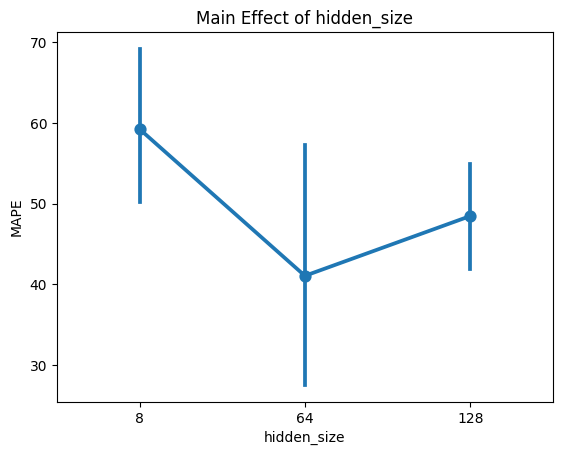

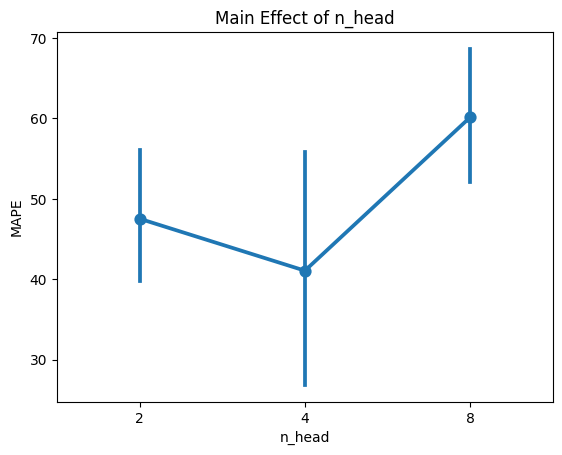

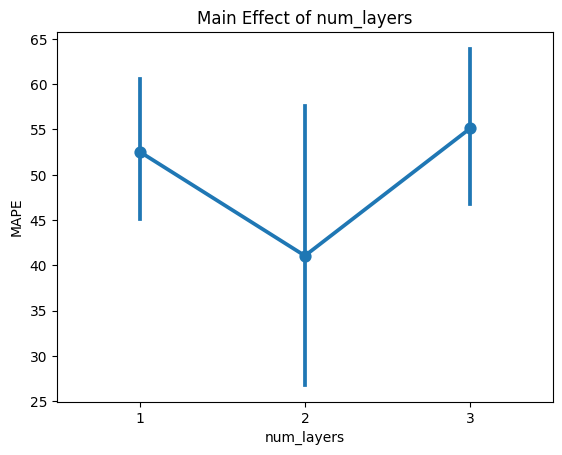

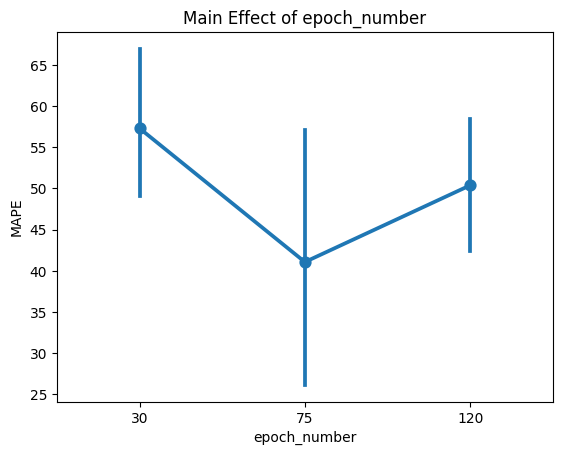

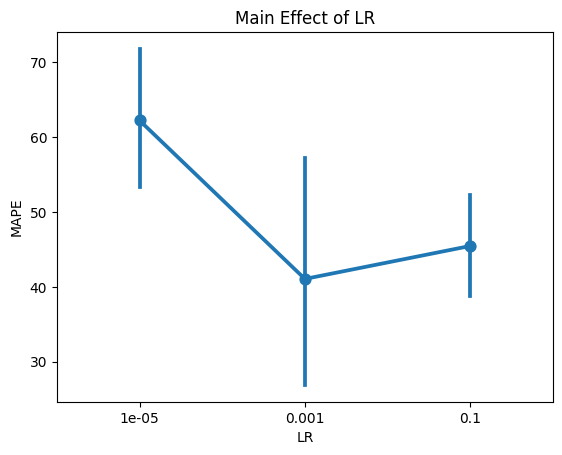

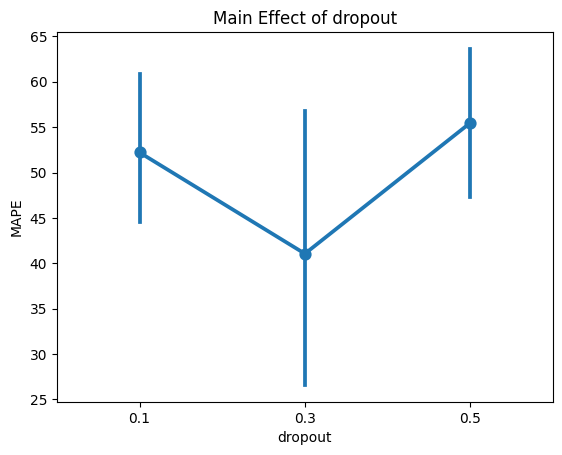

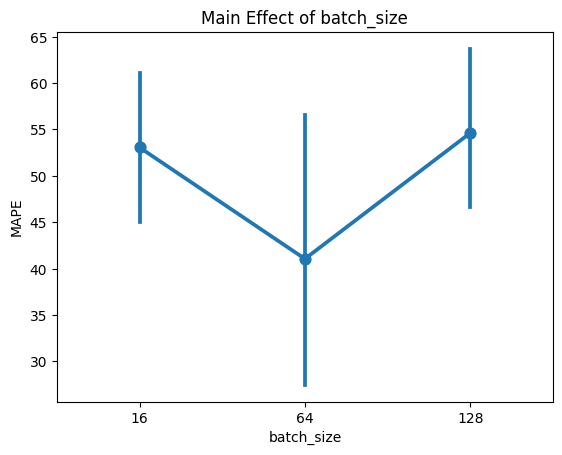

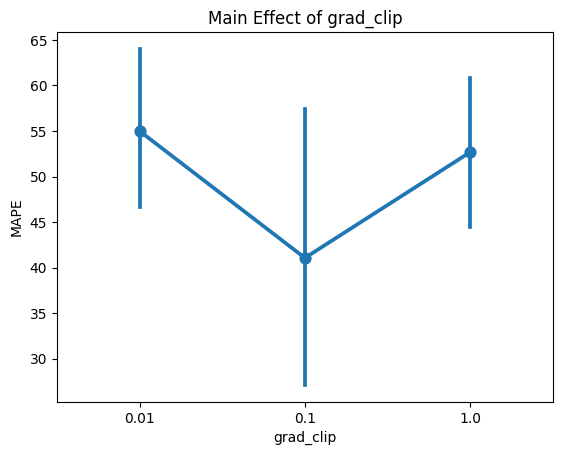

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

for f in factors:
    sns.pointplot(x=f, y='MAPE', data=runs)
    plt.title(f'Main Effect of {f}')
    plt.show()


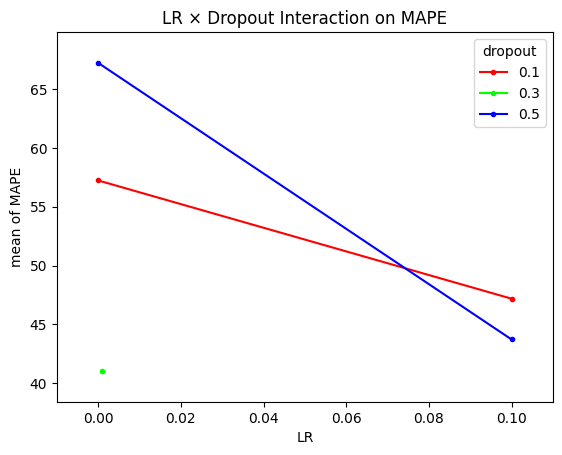

In [17]:
from statsmodels.graphics.factorplots import interaction_plot

interaction_plot(runs['LR'], runs['dropout'], runs['MAPE'])
plt.title('LR × Dropout Interaction on MAPE')
plt.show()
